In [2]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_mse   = mean_squared_error(y_test, lr_preds)

print(f"Linear Regression Test MSE: {lr_mse:.2f}")

Linear Regression Test MSE: 2900.19


Linear Regression  Test MSE: 2900.19
Kernel Ridge (RBF) Test MSE: 3975.65
Kernel Ridge (Poly) Test MSE: 3690.53


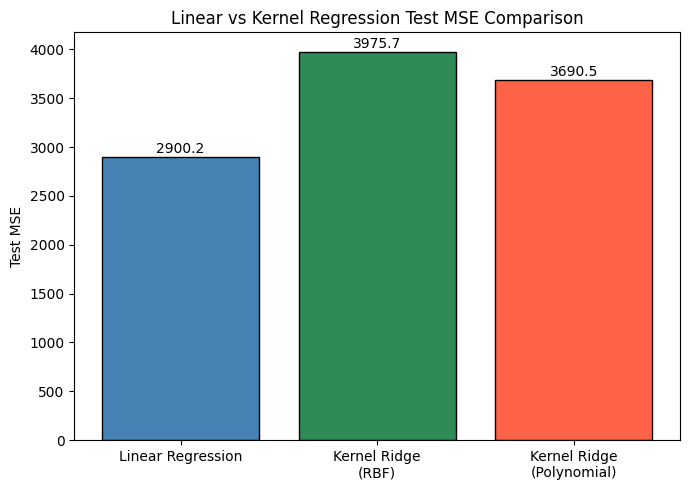

In [5]:
from sklearn.kernel_ridge import KernelRidge
import matplotlib.pyplot as plt

rbf_model = KernelRidge(kernel='rbf', alpha=1.0, gamma=0.1)
rbf_model.fit(X_train, y_train)
rbf_preds = rbf_model.predict(X_test)
rbf_mse   = mean_squared_error(y_test, rbf_preds)


poly_model = KernelRidge(kernel='polynomial', alpha=1.0, degree=3)
poly_model.fit(X_train, y_train)
poly_preds = poly_model.predict(X_test)
poly_mse   = mean_squared_error(y_test, poly_preds)

print(f"Linear Regression  Test MSE: {lr_mse:.2f}")
print(f"Kernel Ridge (RBF) Test MSE: {rbf_mse:.2f}")
print(f"Kernel Ridge (Poly) Test MSE: {poly_mse:.2f}")

fig, ax = plt.subplots(figsize=(7, 5))
models  = ['Linear Regression', 'Kernel Ridge\n(RBF)', 'Kernel Ridge\n(Polynomial)']
mses    = [lr_mse, rbf_mse, poly_mse]
bars    = ax.bar(models, mses, color=['steelblue', 'seagreen', 'tomato'], edgecolor='black')

for bar, mse in zip(bars, mses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{mse:.1f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Test MSE')
ax.set_title('Linear vs Kernel Regression Test MSE Comparison')
plt.tight_layout()
plt.show()